In [1]:
import yaml, json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from analysis_configs import eval_colors_list, legend_kwargs

# Set Seaborn style for better looking plots
sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")  # More accessible color palette
# Import configurations from default_configs.py
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',  # More formal for academic papers
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 22,
    'figure.figsize': (10, 6),  # Good size for single-column papers
    'lines.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.3
})

def results_by_env_to_df_row(filepath, directory):
    # If the file is a json, load it as a json
    full_path = os.path.join(directory, filepath)
    if full_path.endswith(".json"):
        data = json.load(open(full_path))
    elif full_path.endswith(".yaml"):
        data = yaml.safe_load(open(full_path))
    else:
        raise ValueError(f"Unsupported file type, require .json or .yaml: {full_path}")
    for eval, results in data.items():
        row = {'name': filepath, 'env': eval}
        for key, value in results.items():
            row[key] = value
        yield row



In [2]:
# read .json files from subdirs of the current dir
import os


evals_dir = "data/base_llm_evals"
subdirs = [f for f in os.listdir(evals_dir) if os.path.isdir(os.path.join(evals_dir, f))]
filepaths = [os.path.join(subdir, f) for subdir in subdirs for f in os.listdir(os.path.join(evals_dir, subdir)) if f.endswith(".json")]
# Fix: Flatten the generator results into a list of rows
data = []

for filepath in filepaths:
    for row in results_by_env_to_df_row(filepath, evals_dir):
        data.append(row)

df = pd.DataFrame(data)
print(len(df))

df['tokens_per_rollout'] = df['total_tokens_generated'] / df['number_of_episodes']
df['inference_time_per_rollout'] = df['time_taken'] / df['number_of_episodes']

names = df['name'].str.split('/').str[0]
df['model_size'] = names.str.split('_').str[0].str.split('-').str[1]
df['is_4096'] = names.str.split('_').str[3] == '4096' 
df['is_cot'] = names.str.split('_').str[4] == 'cot'
# df.to_csv("results.csv", index=False)

108


In [3]:
df['env'].unique()

array(['FastSnake-Default', 'FrozenLake-NoSlip', 'FrozenLake-Slippery',
       'FrozenLake-BigSlippery', 'Snake-20Step',
       'Snake-20Steps-PoisonAppleAndBanana'], dtype=object)


=== FastSnake-20Steps: Inference Time per Rollout vs Mean Score ===
Saved chart to: charts/Snake_20Step_inference_time.png


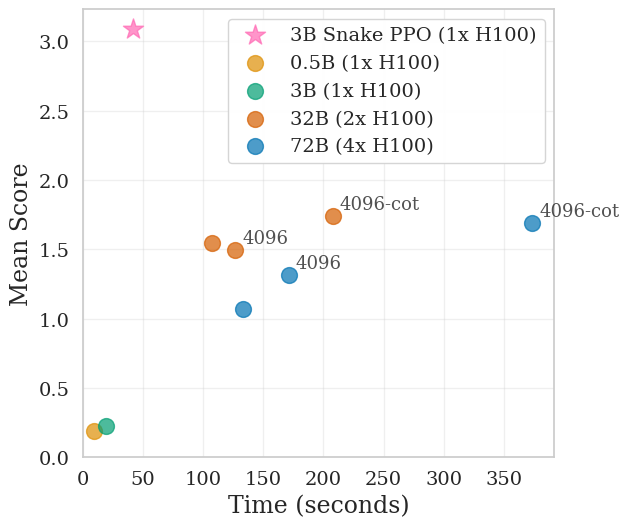


=== FastSnake-Default: Inference Time per Rollout vs Mean Score ===
Saved chart to: charts/FastSnake_Default_inference_time.png


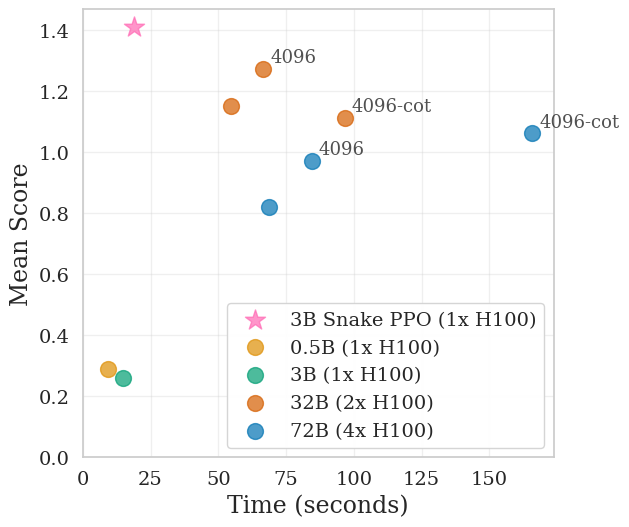


=== FrozenLake-NoSlip: Inference Time per Rollout vs Mean Score ===
Saved chart to: charts/FrozenLake_NoSlip_inference_time.png


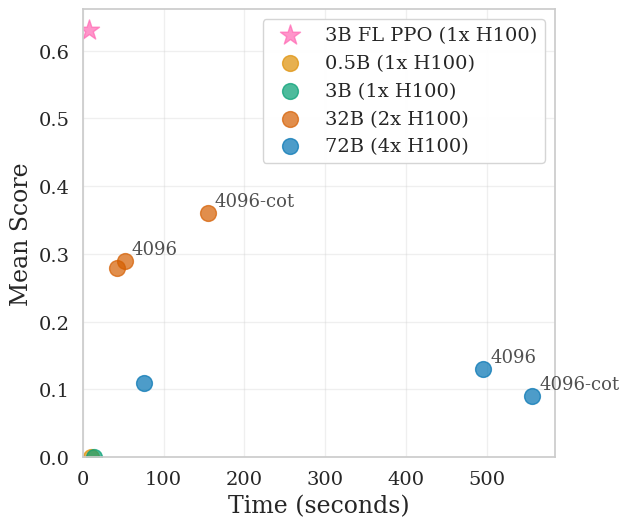


=== FrozenLake-Slippery: Inference Time per Rollout vs Mean Score ===
Saved chart to: charts/FrozenLake_Slippery_inference_time.png


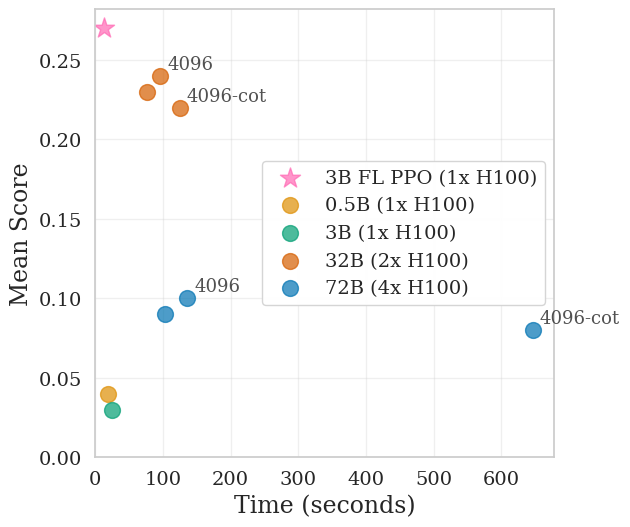

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Create labels in the format {model_size}-{4096/256}(-cot)
def create_label(row):
    model_size = row['model_size']
    context_size = '4096' if row['is_4096'] else '256'
    cot_suffix = '-cot' if row['is_cot'] else ''
    return f"{context_size}{cot_suffix}"

# Create a function to plot scatter charts
def create_scatter_plot(env_name, x_metric, x_label, title_suffix):
    # Filter data for the environment
    env_data = df[df['env'] == env_name].copy()
    
    # Filter: For 0.5B, 3B, and PPO models, only use 256 context size (not 4096)
    env_data = env_data[~((env_data['model_size'].isin(['0.5B', '3B', '3BFSPPO', '3BFLPPO'])) & env_data['is_4096'])]
    
    # Filter: Remove PPO models from environments they weren't trained on
    if 'Snake' in env_name:
        # Remove FLPPO models from Snake environments
        env_data = env_data[~env_data['model_size'].str.contains('FLPPO', na=False)]
    elif 'FrozenLake' in env_name:
        # Remove FSPPO models from FrozenLake environments
        env_data = env_data[~env_data['model_size'].str.contains('FSPPO', na=False)]
    
    env_data['label'] = env_data.apply(create_label, axis=1)
    
    # Create the plot
    plt.figure(figsize=(6.5, 5.5))
    
    # GPU information mapping
    gpu_info = {
        '0.5B': '1x H100',
        '3B': '1x H100', 
        '32B': '2x H100',
        '72B': '4x H100',
        '3BFSPPO': '1x H100',
        '3BFLPPO': '1x H100'
    }
    
    # Define model size order (PPO models first, then ascending by size)
    def get_model_order(model_size):
        if model_size in ['3BFSPPO', '3BFLPPO']:
            return (0, model_size)  # PPO models first
        else:
            # Extract numeric size for ordering
            size_num = float(model_size.replace('B', ''))
            return (1, size_num)  # Regular models ordered by size
    
    # Sort model sizes for consistent legend ordering
    sorted_model_sizes = sorted(env_data['model_size'].unique(), key=get_model_order)
    
    # Plot points with different colors for different model sizes
    for i, model_size in enumerate(sorted_model_sizes):
        model_data = env_data[env_data['model_size'] == model_size]
        color = eval_colors_list[i % len(eval_colors_list)]
        
        # Use star marker for 3BFSPPO/3BFLPPO models
        marker = '*' if model_size in ['3BFSPPO', '3BFLPPO'] else 'o'
        size = 230 if model_size in ['3BFSPPO', '3BFLPPO'] else 130
        
        # Create label with GPU info
        gpu = gpu_info.get(model_size, 'Unknown GPU')
        
        # Custom labels for PPO models
        if model_size == '3BFSPPO':
            display_name = '3B Snake PPO'
        elif model_size == '3BFLPPO':
            display_name = '3B FL PPO'
        else:
            display_name = model_size
            
        label = f'{display_name} ({gpu})'
        
        plt.scatter(model_data[x_metric], 
                   model_data['mean_score'], 
                   c=color, 
                   s=size, 
                   alpha=0.7, 
                   marker=marker,
                   label=label)
        
        # Add labels for each point
        for j, row in model_data.iterrows():
            if row['label'] == '256':
                continue
            plt.annotate(row['label'], 
                        (row[x_metric], row['mean_score']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=13, alpha=0.8)
    
    plt.ylim(bottom=0)  # Set y-axis minimum to 0 while keeping auto maximum
    plt.xlim(left=0)  # Set x-axis minimum to 0 while keeping auto maximum
    plt.xlabel(x_label, fontsize=17)
    plt.ylabel('Mean Score', fontsize=17)
    # plt.title(f'{title_suffix}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(**legend_kwargs)
    plt.tight_layout()
    
    # Save inference time charts to analysis/charts directory
    if 'time' in x_label.lower() or 'inference' in x_label.lower():
        import os
        os.makedirs('charts', exist_ok=True)
        
        # Create filename from environment and metric
        env_clean = env_name.replace('-', '_').replace(' ', '_')
        filename = f'{env_clean}_inference_time.png'
        filepath = f'charts/{filename}'
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved chart to: {filepath}")
    
    plt.show()
    
    return env_data

# Create all 4 charts
# print("=== FastSnake-20Steps: Tokens per Rollout vs Mean Score ===")
# fastsnake_tokens = create_scatter_plot('Snake-20Step', 'tokens_per_rollout', 'Tokens per Rollout', 'Snake, 20 Steps')

print("\n=== FastSnake-20Steps: Inference Time per Rollout vs Mean Score ===")
fastsnake_time = create_scatter_plot('Snake-20Step', 'time_taken', 'Time (seconds)', 'Snake, 20 Steps')

# print("=== FastSnake-Default: Tokens per Rollout vs Mean Score ===")
# fastsnake_tokens = create_scatter_plot('FastSnake-Default', 'tokens_per_rollout', 'Tokens per Rollout', 'Snake, 8 Steps')

print("\n=== FastSnake-Default: Inference Time per Rollout vs Mean Score ===")
fastsnake_time = create_scatter_plot('FastSnake-Default', 'time_taken', 'Time (seconds)', 'Snake, 8 Steps')

# print("\n=== FrozenLake-NoSlip: Tokens per Rollout vs Mean Score ===")
# frozenlake_tokens = create_scatter_plot('FrozenLake-NoSlip', 'tokens_per_rollout', 'Tokens per Rollout', 'Frozen Lake, No Slip')

print("\n=== FrozenLake-NoSlip: Inference Time per Rollout vs Mean Score ===")
frozenlake_time = create_scatter_plot('FrozenLake-NoSlip', 'time_taken', 'Time (seconds)', 'Frozen Lake, No Slip')

# print("\n=== FrozenLake-Slippery: Tokens per Rollout vs Mean Score ===")
# frozenlake_tokens = create_scatter_plot('FrozenLake-Slippery', 'tokens_per_rollout', 'Tokens per Rollout', 'Frozen Lake, Slippery')

print("\n=== FrozenLake-Slippery: Inference Time per Rollout vs Mean Score ===")
frozenlake_time = create_scatter_plot('FrozenLake-Slippery', 'time_taken', 'Time (seconds)', 'Frozen Lake, Slippery')
